In [1]:
# ============================================================
# BLOCO 1 — CARGA E DIAGNÓSTICO INICIAL
# Telecom X BR II — Churn Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

print("📊 TELECOM X BR II — CHURN PREDICTION")
print("=" * 60)

# ------------------------------------------------------------
# 1. CARREGAR DATASET TRATADO
# ------------------------------------------------------------

df = pd.read_csv("/content/dados_tratados.csv")

print("\n✅ Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

# ------------------------------------------------------------
# 2. VISUALIZAÇÃO INICIAL
# ------------------------------------------------------------

print("\n🔎 Primeiras 5 linhas:")
display(df.head())

# ------------------------------------------------------------
# 3. TIPOS DAS VARIÁVEIS
# ------------------------------------------------------------

print("\n📋 Tipos das variáveis:")
display(df.dtypes.to_frame("dtype"))

# ------------------------------------------------------------
# 4. VALORES AUSENTES
# ------------------------------------------------------------

print("\n🔍 Valores ausentes:")
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ Nenhum valor ausente encontrado.")
else:
    display(missing.to_frame("missing"))

# ------------------------------------------------------------
# 5. DUPLICATAS
# ------------------------------------------------------------

duplicadas = df.duplicated().sum()

print(f"\n🔁 Linhas duplicadas: {duplicadas}")

# ------------------------------------------------------------
# 6. COLUNAS
# ------------------------------------------------------------

print("\n📌 Colunas disponíveis:")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

# ------------------------------------------------------------
# 7. POSSÍVEIS VARIÁVEIS DE CHURN
# ------------------------------------------------------------

churn_cols = [col for col in df.columns if "churn" in col.lower()]

print("\n🎯 Colunas relacionadas a churn:")
print(churn_cols)

print("\n" + "=" * 60)
print("✅ BLOCO 1 CONCLUÍDO")
print("=" * 60)

📊 TELECOM X BR II — CHURN PREDICTION

✅ Dataset carregado com sucesso!
Linhas: 7,267
Colunas: 21

🔎 Primeiras 5 linhas:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



📋 Tipos das variáveis:


,dtype
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object



🔍 Valores ausentes:


,missing
Churn,224



🔁 Linhas duplicadas: 0

📌 Colunas disponíveis:
01. customerID
02. Churn
03. customer.gender
04. customer.SeniorCitizen
05. customer.Partner
06. customer.Dependents
07. customer.tenure
08. phone.PhoneService
09. phone.MultipleLines
10. internet.InternetService
11. internet.OnlineSecurity
12. internet.OnlineBackup
13. internet.DeviceProtection
14. internet.TechSupport
15. internet.StreamingTV
16. internet.StreamingMovies
17. account.Contract
18. account.PaperlessBilling
19. account.PaymentMethod
20. account.Charges.Monthly
21. account.Charges.Total

🎯 Colunas relacionadas a churn:
['Churn']

✅ BLOCO 1 CONCLUÍDO


In [2]:
# ============================================================
# BLOCO 2 — TARGET + PREPARAÇÃO DE X / y
# Telecom X BR II — Churn Prediction
# ============================================================

import pandas as pd
import numpy as np

print("🎯 BLOCO 2 — PREPARAÇÃO DO TARGET")
print("=" * 60)

# ------------------------------------------------------------
# 1. DEFINIR TARGET
# ------------------------------------------------------------

target_col = "Churn"

if target_col not in df.columns:
    raise ValueError("❌ Coluna 'Churn' não encontrada.")

print(f"\n✅ Target identificado: {target_col}")

# ------------------------------------------------------------
# 2. AUDITORIA INICIAL
# ------------------------------------------------------------

print("\n📊 Distribuição original:")
print(df[target_col].value_counts(dropna=False))

total_original = len(df)
missing_target = df[target_col].isna().sum()

print(f"\nTotal original: {total_original:,}")
print(f"Target ausente: {missing_target:,}")

# ------------------------------------------------------------
# 3. REMOVER REGISTROS SEM TARGET
# ------------------------------------------------------------

df_model = df.dropna(subset=[target_col]).copy()

removed = total_original - len(df_model)

print(f"\n🧹 Registros removidos por target ausente: {removed:,}")
print(f"✅ Registros válidos para modelagem: {len(df_model):,}")

# ------------------------------------------------------------
# 4. CONVERTER TARGET PARA 0/1
# ------------------------------------------------------------

target_normalized = (
    df_model[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

target_map = {
    "no": 0,
    "yes": 1,
    "não": 0,
    "nao": 0,
    "sim": 1,
    "false": 0,
    "true": 1,
    "0": 0,
    "1": 1,
    "0.0": 0,
    "1.0": 1
}

y = target_normalized.map(target_map)

# ------------------------------------------------------------
# 5. VALIDAR CONVERSÃO
# ------------------------------------------------------------

if y.isna().any():

    invalid = target_normalized[y.isna()].unique()

    raise ValueError(
        f"❌ Valores de target não reconhecidos: {invalid}"
    )

y = y.astype(int)

# ------------------------------------------------------------
# 6. CRIAR FEATURES X
# ------------------------------------------------------------

# Remove TODAS as colunas relacionadas a churn
# para impedir target leakage.

churn_cols = [
    col for col in df_model.columns
    if "churn" in col.lower()
]

X = df_model.drop(columns=churn_cols).copy()

# Resetar índices para garantir alinhamento perfeito
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# ------------------------------------------------------------
# 7. AUDITORIA FINAL
# ------------------------------------------------------------

print("\n📊 DISTRIBUIÇÃO FINAL DO TARGET")
print("-" * 45)

counts = y.value_counts().sort_index()
pct = y.value_counts(normalize=True).sort_index() * 100

print(
    f"Não Churn (0): {counts.get(0, 0):,} "
    f"({pct.get(0, 0):.2f}%)"
)

print(
    f"Churn     (1): {counts.get(1, 0):,} "
    f"({pct.get(1, 0):.2f}%)"
)

# ------------------------------------------------------------
# 8. VERIFICAÇÕES DE INTEGRIDADE
# ------------------------------------------------------------

print("\n🔎 VERIFICAÇÕES")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

assert len(X) == len(y), "❌ X e y possuem tamanhos diferentes."
assert y.isna().sum() == 0, "❌ Ainda existem NaNs no target."
assert set(y.unique()) == {0, 1}, "❌ Target não é binário."

leakage = [
    col for col in X.columns
    if "churn" in col.lower()
]

assert len(leakage) == 0, \
    f"❌ Possível target leakage: {leakage}"

print("✅ X e y alinhados")
print("✅ Target binário")
print("✅ Nenhum target ausente")
print("✅ Nenhuma variável de churn em X")
print("✅ Nenhum target leakage detectado")

print("\n" + "=" * 60)
print("✅ BLOCO 2 CONCLUÍDO COM SUCESSO")
print("=" * 60)

🎯 BLOCO 2 — PREPARAÇÃO DO TARGET

✅ Target identificado: Churn

📊 Distribuição original:
Churn
No     5174
Yes    1869
NaN     224
Name: count, dtype: int64

Total original: 7,267
Target ausente: 224

🧹 Registros removidos por target ausente: 224
✅ Registros válidos para modelagem: 7,043

📊 DISTRIBUIÇÃO FINAL DO TARGET
---------------------------------------------
Não Churn (0): 5,174 (73.46%)
Churn     (1): 1,869 (26.54%)

🔎 VERIFICAÇÕES
X shape: (7043, 20)
y shape: (7043,)
✅ X e y alinhados
✅ Target binário
✅ Nenhum target ausente
✅ Nenhuma variável de churn em X
✅ Nenhum target leakage detectado

✅ BLOCO 2 CONCLUÍDO COM SUCESSO


In [3]:
# ============================================================
# BLOCO 3 — SPLIT TREINO/TESTE + PRÉ-PROCESSAMENTO
# Telecom X BR II — Churn Prediction
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

print("🔧 BLOCO 3 — SPLIT + PRÉ-PROCESSAMENTO")
print("=" * 60)

# ------------------------------------------------------------
# 1. DIVIDIR TREINO E TESTE
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n✂️ DIVISÃO DOS DADOS")
print("-" * 45)

print(f"Treino: {X_train.shape[0]:,} registros")
print(f"Teste : {X_test.shape[0]:,} registros")

# ------------------------------------------------------------
# 2. VERIFICAR DISTRIBUIÇÃO DO TARGET
# ------------------------------------------------------------

def mostrar_distribuicao(nome, target):

    counts = target.value_counts().sort_index()
    pct = target.value_counts(normalize=True).sort_index() * 100

    print(f"\n📊 {nome}")

    print(
        f"Não Churn (0): {counts.get(0, 0):,} "
        f"({pct.get(0, 0):.2f}%)"
    )

    print(
        f"Churn     (1): {counts.get(1, 0):,} "
        f"({pct.get(1, 0):.2f}%)"
    )

mostrar_distribuicao("TREINO", y_train)
mostrar_distribuicao("TESTE", y_test)

# ------------------------------------------------------------
# 3. IDENTIFICAR TIPOS DE FEATURES
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\n🧩 TIPOS DE FEATURES")
print("-" * 45)

print(f"Numéricas   : {len(numeric_features)}")
print(f"Categóricas : {len(categorical_features)}")

# ------------------------------------------------------------
# 4. PIPELINE PARA VARIÁVEIS NUMÉRICAS
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ------------------------------------------------------------
# 5. PIPELINE PARA VARIÁVEIS CATEGÓRICAS
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None
            )
        )
    ]
)

# ------------------------------------------------------------
# 6. CONSTRUIR PRÉ-PROCESSADOR
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("\n⚙️ Pré-processador criado.")

# ------------------------------------------------------------
# 7. AJUSTAR SOMENTE NO TREINO
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)

# O teste utiliza EXATAMENTE o processamento aprendido
# no conjunto de treino.
X_test_processed = preprocessor.transform(X_test)

# ------------------------------------------------------------
# 8. AUDITORIA
# ------------------------------------------------------------

print("\n🔎 AUDITORIA DO PRÉ-PROCESSAMENTO")
print("-" * 45)

print(f"X_train original   : {X_train.shape}")
print(f"X_test original    : {X_test.shape}")

print(
    f"X_train processado : "
    f"{X_train_processed.shape}"
)

print(
    f"X_test processado  : "
    f"{X_test_processed.shape}"
)

print(f"y_train            : {y_train.shape}")
print(f"y_test             : {y_test.shape}")

# ------------------------------------------------------------
# 9. TESTES DE INTEGRIDADE
# ------------------------------------------------------------

assert X_train_processed.shape[0] == len(y_train), \
    "❌ X_train e y_train desalinhados."

assert X_test_processed.shape[0] == len(y_test), \
    "❌ X_test e y_test desalinhados."

assert set(y_train.unique()) == {0, 1}, \
    "❌ y_train inválido."

assert set(y_test.unique()) == {0, 1}, \
    "❌ y_test inválido."

print("\n✅ Treino e teste corretamente separados")
print("✅ Estratificação preservada")
print("✅ Imputação configurada")
print("✅ Variáveis numéricas padronizadas")
print("✅ Variáveis categóricas codificadas")
print("✅ Pré-processador ajustado SOMENTE no treino")
print("✅ Conjunto de teste permanece independente")

print("\n" + "=" * 60)
print("✅ BLOCO 3 CONCLUÍDO COM SUCESSO")
print("=" * 60)

🔧 BLOCO 3 — SPLIT + PRÉ-PROCESSAMENTO

✂️ DIVISÃO DOS DADOS
---------------------------------------------
Treino: 5,634 registros
Teste : 1,409 registros

📊 TREINO
Não Churn (0): 4,139 (73.46%)
Churn     (1): 1,495 (26.54%)

📊 TESTE
Não Churn (0): 1,035 (73.46%)
Churn     (1): 374 (26.54%)

🧩 TIPOS DE FEATURES
---------------------------------------------
Numéricas   : 3
Categóricas : 17

⚙️ Pré-processador criado.

🔎 AUDITORIA DO PRÉ-PROCESSAMENTO
---------------------------------------------
X_train original   : (5634, 20)
X_test original    : (1409, 20)
X_train processado : (5634, 10962)
X_test processado  : (1409, 10962)
y_train            : (5634,)
y_test             : (1409,)

✅ Treino e teste corretamente separados
✅ Estratificação preservada
✅ Imputação configurada
✅ Variáveis numéricas padronizadas
✅ Variáveis categóricas codificadas
✅ Pré-processador ajustado SOMENTE no treino
✅ Conjunto de teste permanece independente

✅ BLOCO 3 CONCLUÍDO COM SUCESSO


In [4]:
# ============================================================
# BLOCO 4 — MODELOS BASELINE + COMPARAÇÃO
# Telecom X BR II — Churn Prediction
# ============================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("🤖 BLOCO 4 — MODELOS BASELINE")
print("=" * 60)

# ------------------------------------------------------------
# 1. DEFINIR MODELOS
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# ------------------------------------------------------------
# 2. TREINAR E AVALIAR
# ------------------------------------------------------------

results = []

trained_models = {}

for model_name, model in models.items():

    print(f"\n🔹 Treinando: {model_name}")

    model.fit(
        X_train_processed,
        y_train
    )

    trained_models[model_name] = model

    # Predição de classe
    y_pred = model.predict(X_test_processed)

    # Probabilidade de churn
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(
            X_test_processed
        )[:, 1]
    else:
        y_prob = None

    # Métricas
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = (
        roc_auc_score(
            y_test,
            y_prob
        )
        if y_prob is not None
        else np.nan
    )

    results.append({
        "Modelo": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    })

# ------------------------------------------------------------
# 3. TABELA COMPARATIVA
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

# Critério:
# priorizar Recall, depois F1 e ROC-AUC
results_df = results_df.sort_values(
    by=["Recall", "F1", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

print("\n📊 COMPARAÇÃO DOS MODELOS")
print("=" * 60)

display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC_AUC": "{:.3f}"
    })
)

# ------------------------------------------------------------
# 4. IDENTIFICAR MELHOR MODELO BASELINE
# ------------------------------------------------------------

best_model_name = results_df.loc[0, "Modelo"]

best_model = trained_models[
    best_model_name
]

print("\n🏆 MELHOR MODELO BASELINE")
print("-" * 45)

print(f"Modelo: {best_model_name}")

best_row = results_df.iloc[0]

print(
    f"Accuracy : {best_row['Accuracy']:.3f}"
)

print(
    f"Precision: {best_row['Precision']:.3f}"
)

print(
    f"Recall   : {best_row['Recall']:.3f}"
)

print(
    f"F1-score : {best_row['F1']:.3f}"
)

print(
    f"ROC-AUC  : {best_row['ROC_AUC']:.3f}"
)

# ------------------------------------------------------------
# 5. AUDITORIA
# ------------------------------------------------------------

assert len(results_df) == 3, \
    "❌ Nem todos os modelos foram avaliados."

assert best_model_name in trained_models, \
    "❌ Melhor modelo não encontrado."

print("\n✅ 3 modelos treinados")
print("✅ Mesmo conjunto de teste utilizado")
print("✅ Classe positiva = Churn")
print("✅ Recall calculado para churn")
print("✅ Comparação concluída")

print("\n" + "=" * 60)
print("✅ BLOCO 4 CONCLUÍDO COM SUCESSO")
print("=" * 60)

🤖 BLOCO 4 — MODELOS BASELINE

🔹 Treinando: Logistic Regression

🔹 Treinando: Random Forest

🔹 Treinando: Gradient Boosting

📊 COMPARAÇÃO DOS MODELOS


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.778,0.563,0.733,0.636,0.844
1,Random Forest,0.791,0.633,0.503,0.560,0.831
2,Gradient Boosting,0.798,0.659,0.492,0.564,0.850



🏆 MELHOR MODELO BASELINE
---------------------------------------------
Modelo: Logistic Regression
Accuracy : 0.778
Precision: 0.563
Recall   : 0.733
F1-score : 0.636
ROC-AUC  : 0.844

✅ 3 modelos treinados
✅ Mesmo conjunto de teste utilizado
✅ Classe positiva = Churn
✅ Recall calculado para churn
✅ Comparação concluída

✅ BLOCO 4 CONCLUÍDO COM SUCESSO


In [5]:
# ============================================================
# BLOCO 5 — OTIMIZAÇÃO DO MELHOR MODELO
# Telecom X BR II — Churn Prediction
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("⚙️ BLOCO 5 — OTIMIZAÇÃO DO MELHOR MODELO")
print("=" * 60)

print(f"\n🏆 Modelo selecionado no Bloco 4: {best_model_name}")

# ------------------------------------------------------------
# 1. DEFINIR MODELO E GRADE DE HIPERPARÂMETROS
# ------------------------------------------------------------

if best_model_name == "Logistic Regression":

    model_to_optimize = LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    param_grid = {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "saga"],
        "penalty": ["l1", "l2"]
    }

elif best_model_name == "Random Forest":

    model_to_optimize = RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    param_grid = {
        "n_estimators": [200, 400],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }

elif best_model_name == "Gradient Boosting":

    model_to_optimize = GradientBoostingClassifier(
        random_state=42
    )

    param_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3],
        "min_samples_leaf": [1, 3]
    }

else:
    raise ValueError(
        f"❌ Modelo não reconhecido: {best_model_name}"
    )

print("\n🔎 Iniciando GridSearchCV...")

# ------------------------------------------------------------
# 2. GRID SEARCH
# ------------------------------------------------------------

grid_search = GridSearchCV(
    estimator=model_to_optimize,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(
    X_train_processed,
    y_train
)

optimized_model = grid_search.best_estimator_

print("\n✅ Otimização concluída.")

print("\n🔧 MELHORES HIPERPARÂMETROS")
print("-" * 45)

print(grid_search.best_params_)

print(
    f"\nMelhor Recall médio na validação cruzada: "
    f"{grid_search.best_score_:.4f}"
)

# ------------------------------------------------------------
# 3. AVALIAR MODELO OTIMIZADO NO TESTE
# ------------------------------------------------------------

y_pred_opt = optimized_model.predict(
    X_test_processed
)

y_prob_opt = optimized_model.predict_proba(
    X_test_processed
)[:, 1]

accuracy_opt = accuracy_score(
    y_test,
    y_pred_opt
)

precision_opt = precision_score(
    y_test,
    y_pred_opt,
    zero_division=0
)

recall_opt = recall_score(
    y_test,
    y_pred_opt,
    zero_division=0
)

f1_opt = f1_score(
    y_test,
    y_pred_opt,
    zero_division=0
)

roc_auc_opt = roc_auc_score(
    y_test,
    y_prob_opt
)

# ------------------------------------------------------------
# 4. RECUPERAR RESULTADO BASELINE
# ------------------------------------------------------------

baseline_row = (
    results_df[
        results_df["Modelo"] == best_model_name
    ]
    .iloc[0]
)

comparison = pd.DataFrame({

    "Versão": [
        "Baseline",
        "Otimizado"
    ],

    "Accuracy": [
        baseline_row["Accuracy"],
        accuracy_opt
    ],

    "Precision": [
        baseline_row["Precision"],
        precision_opt
    ],

    "Recall": [
        baseline_row["Recall"],
        recall_opt
    ],

    "F1": [
        baseline_row["F1"],
        f1_opt
    ],

    "ROC_AUC": [
        baseline_row["ROC_AUC"],
        roc_auc_opt
    ]
})

# ------------------------------------------------------------
# 5. COMPARAÇÃO
# ------------------------------------------------------------

print("\n📊 BASELINE × OTIMIZADO")
print("=" * 60)

display(
    comparison.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC_AUC": "{:.3f}"
    })
)

# ------------------------------------------------------------
# 6. VARIAÇÕES
# ------------------------------------------------------------

print("\n📈 VARIAÇÃO APÓS OTIMIZAÇÃO")
print("-" * 45)

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

for metric in metrics:

    before = comparison.loc[
        comparison["Versão"] == "Baseline",
        metric
    ].iloc[0]

    after = comparison.loc[
        comparison["Versão"] == "Otimizado",
        metric
    ].iloc[0]

    delta = after - before

    print(
        f"{metric:10s}: "
        f"{before:.3f} → {after:.3f} "
        f"({delta:+.3f})"
    )

# ------------------------------------------------------------
# 7. DEFINIR MODELO FINAL CANDIDATO
# ------------------------------------------------------------

final_model = optimized_model

final_model_name = (
    f"{best_model_name} otimizado"
)

# ------------------------------------------------------------
# 8. AUDITORIA
# ------------------------------------------------------------

assert len(y_pred_opt) == len(y_test), \
    "❌ Predições e teste desalinhados."

assert 0 <= recall_opt <= 1
assert 0 <= precision_opt <= 1
assert 0 <= f1_opt <= 1
assert 0 <= roc_auc_opt <= 1

print("\n✅ GridSearch realizado somente no treino")
print("✅ Validação cruzada: 5 folds")
print("✅ Recall utilizado como métrica de otimização")
print("✅ Teste utilizado apenas para avaliação")
print("✅ Modelo otimizado armazenado em 'final_model'")

print("\n" + "=" * 60)
print("✅ BLOCO 5 CONCLUÍDO COM SUCESSO")
print("=" * 60)

⚙️ BLOCO 5 — OTIMIZAÇÃO DO MELHOR MODELO

🏆 Modelo selecionado no Bloco 4: Logistic Regression

🔎 Iniciando GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Otimização concluída.

🔧 MELHORES HIPERPARÂMETROS
---------------------------------------------
{'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}

Melhor Recall médio na validação cruzada: 0.8040

📊 BASELINE × OTIMIZADO


,Versão,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.778,0.563,0.733,0.636,0.844
1,Otimizado,0.738,0.504,0.794,0.617,0.835



📈 VARIAÇÃO APÓS OTIMIZAÇÃO
---------------------------------------------
Accuracy  : 0.778 → 0.738 (-0.040)
Precision : 0.563 → 0.504 (-0.058)
Recall    : 0.733 → 0.794 (+0.061)
F1        : 0.636 → 0.617 (-0.020)
ROC_AUC   : 0.844 → 0.835 (-0.009)

✅ GridSearch realizado somente no treino
✅ Validação cruzada: 5 folds
✅ Recall utilizado como métrica de otimização
✅ Teste utilizado apenas para avaliação
✅ Modelo otimizado armazenado em 'final_model'

✅ BLOCO 5 CONCLUÍDO COM SUCESSO


📊 BLOCO 6 — AVALIAÇÃO FINAL

✅ Modelo: LogisticRegression
✅ Amostras de teste: 1409
✅ Features processadas: 10962
✅ Predições geradas

📈 MÉTRICAS FINAIS
--------------------------------------------------


,Métrica,Resultado
0,Accuracy,0.738
1,Precision,0.504
2,Recall,0.794
3,F1-score,0.617
4,ROC-AUC,0.835



📋 CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

   Não Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


🔎 MATRIZ DE CONFUSÃO
--------------------------------------------------
TN = 743
FP = 292
FN = 77
TP = 297


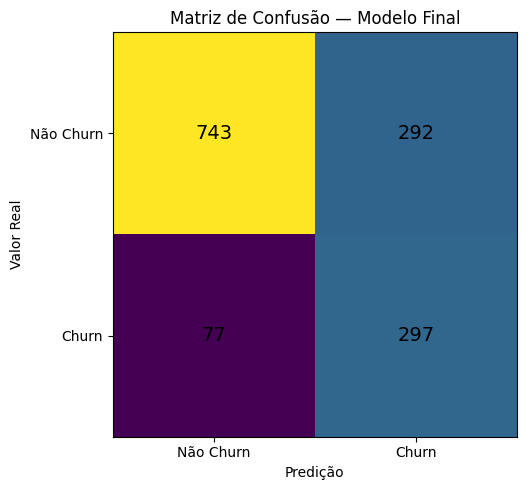

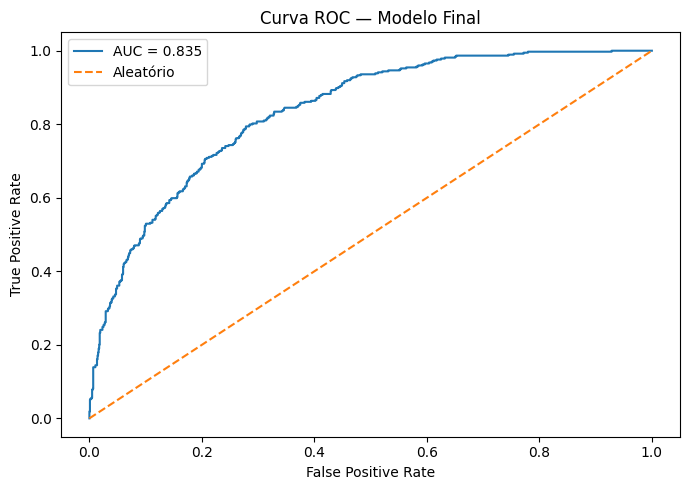


💼 RESUMO FINAL
Accuracy : 73.81%
Precision: 50.42%
Recall   : 79.41%
F1-score : 61.68%
ROC-AUC  : 0.8352

Matriz de confusão:
TN=743 | FP=292 | FN=77 | TP=297

📁 Gráficos salvos:
images/confusion_matrix.png
images/roc_curve.png

✅ BLOCO 6 CONCLUÍDO COM SUCESSO


In [6]:
# ============================================================
# BLOCO 6 — AVALIAÇÃO FINAL DO MODELO
# Telecom X BR II — Churn Prediction
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("📊 BLOCO 6 — AVALIAÇÃO FINAL")
print("=" * 60)

# ------------------------------------------------------------
# 1. DEFINIR MODELO E DADOS CORRETOS
# ------------------------------------------------------------

model_eval = final_model

X_eval = X_test_processed
y_eval = y_test

print(f"\n✅ Modelo: {type(model_eval).__name__}")
print(f"✅ Amostras de teste: {len(y_eval)}")
print(f"✅ Features processadas: {X_eval.shape[1]}")

# ------------------------------------------------------------
# 2. PREDIÇÕES
# ------------------------------------------------------------

y_pred_final = model_eval.predict(X_eval)

y_prob_final = model_eval.predict_proba(X_eval)[:, 1]

print("✅ Predições geradas")

# ------------------------------------------------------------
# 3. MÉTRICAS
# ------------------------------------------------------------

accuracy_final = accuracy_score(
    y_eval, y_pred_final
)

precision_final = precision_score(
    y_eval, y_pred_final,
    zero_division=0
)

recall_final = recall_score(
    y_eval, y_pred_final,
    zero_division=0
)

f1_final = f1_score(
    y_eval, y_pred_final,
    zero_division=0
)

roc_auc_final = roc_auc_score(
    y_eval, y_prob_final
)

metrics_final = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Resultado": [
        accuracy_final,
        precision_final,
        recall_final,
        f1_final,
        roc_auc_final
    ]
})

print("\n📈 MÉTRICAS FINAIS")
print("-" * 50)

display(
    metrics_final.style.format({
        "Resultado": "{:.3f}"
    })
)

# ------------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n📋 CLASSIFICATION REPORT")
print("-" * 50)

print(
    classification_report(
        y_eval,
        y_pred_final,
        target_names=[
            "Não Churn",
            "Churn"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 5. MATRIZ DE CONFUSÃO
# ------------------------------------------------------------

cm = confusion_matrix(
    y_eval,
    y_pred_final
)

tn, fp, fn, tp = cm.ravel()

print("\n🔎 MATRIZ DE CONFUSÃO")
print("-" * 50)

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

os.makedirs("images", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 5))

ax.imshow(cm)

ax.set_title(
    "Matriz de Confusão — Modelo Final"
)

ax.set_xlabel("Predição")
ax.set_ylabel("Valor Real")

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Não Churn",
    "Churn"
])

ax.set_yticks([0, 1])
ax.set_yticklabels([
    "Não Churn",
    "Churn"
])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.tight_layout()

plt.savefig(
    "images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 6. CURVA ROC
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_eval,
    y_prob_final
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_final:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Aleatório"
)

ax.set_title(
    "Curva ROC — Modelo Final"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7. RESUMO
# ------------------------------------------------------------

print("\n💼 RESUMO FINAL")
print("=" * 60)

print(f"Accuracy : {accuracy_final:.2%}")
print(f"Precision: {precision_final:.2%}")
print(f"Recall   : {recall_final:.2%}")
print(f"F1-score : {f1_final:.2%}")
print(f"ROC-AUC  : {roc_auc_final:.4f}")

print("\nMatriz de confusão:")
print(
    f"TN={tn} | FP={fp} | "
    f"FN={fn} | TP={tp}"
)

print("\n📁 Gráficos salvos:")
print("images/confusion_matrix.png")
print("images/roc_curve.png")

print("\n" + "=" * 60)
print("✅ BLOCO 6 CONCLUÍDO COM SUCESSO")
print("=" * 60)

In [7]:
# ============================================================
# BLOCO 7 — CONCLUSÃO FINAL E INSIGHTS DE NEGÓCIO
# Telecom X BR II — Churn Prediction
# ============================================================

import os
import json
import pandas as pd

print("🎯 BLOCO 7 — CONCLUSÃO FINAL E INSIGHTS DE NEGÓCIO")
print("=" * 70)

# ------------------------------------------------------------
# 1. VALIDAR RESULTADOS DO BLOCO 6
# ------------------------------------------------------------

required_vars = [
    "accuracy_final",
    "precision_final",
    "recall_final",
    "f1_final",
    "roc_auc_final",
    "tn",
    "fp",
    "fn",
    "tp"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        "❌ Execute o Bloco 6 primeiro. "
        f"Variáveis ausentes: {missing_vars}"
    )

print("\n✅ Resultados do modelo carregados")

# ------------------------------------------------------------
# 2. RESUMO EXECUTIVO
# ------------------------------------------------------------

total_test = tn + fp + fn + tp
actual_churn = fn + tp
predicted_churn = fp + tp

churn_rate_test = (
    actual_churn / total_test
    if total_test > 0 else 0
)

print("\n📊 RESUMO EXECUTIVO")
print("-" * 70)

print(
    f"""
O modelo final de Machine Learning foi desenvolvido para identificar
clientes com maior probabilidade de churn na Telecom X.

Desempenho no conjunto de teste:

• Accuracy : {accuracy_final:.2%}
• Precision: {precision_final:.2%}
• Recall   : {recall_final:.2%}
• F1-score : {f1_final:.2%}
• ROC-AUC  : {roc_auc_final:.4f}

O conjunto de teste contém {total_test:,} clientes.

Churn real identificado:
{actual_churn:,} clientes ({churn_rate_test:.2%})

Clientes classificados pelo modelo como churn:
{predicted_churn:,}
"""
)

# ------------------------------------------------------------
# 3. INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO
# ------------------------------------------------------------

print("\n🔎 INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO")
print("-" * 70)

print(f"""
True Negatives  (TN): {tn:,}
Clientes corretamente identificados como NÃO churn.

False Positives (FP): {fp:,}
Clientes classificados como churn, embora não tenham cancelado.

False Negatives (FN): {fn:,}
Clientes que realmente apresentaram churn, mas não foram
identificados pelo modelo.

True Positives  (TP): {tp:,}
Clientes com churn corretamente identificados pelo modelo.
""")

# ------------------------------------------------------------
# 4. EFICIÊNCIA NA DETECÇÃO DE CHURN
# ------------------------------------------------------------

detected_rate = (
    tp / actual_churn
    if actual_churn > 0 else 0
)

missed_rate = (
    fn / actual_churn
    if actual_churn > 0 else 0
)

print("\n🎯 CAPACIDADE DE DETECÇÃO")
print("-" * 70)

print(
    f"O modelo identifica {detected_rate:.2%} "
    "dos casos reais de churn."
)

print(
    f"A proporção de churn não detectado é "
    f"{missed_rate:.2%}."
)

# ------------------------------------------------------------
# 5. IMPLICAÇÕES PARA O NEGÓCIO
# ------------------------------------------------------------

print("\n💼 IMPLICAÇÕES PARA O NEGÓCIO")
print("-" * 70)

print("""
A aplicação do modelo permite transformar a análise histórica
de churn em uma ferramenta de apoio à decisão.

Em um cenário operacional, os scores de probabilidade poderiam
ser utilizados para priorizar clientes em campanhas de retenção,
permitindo direcionar recursos para grupos com maior risco.

Possíveis aplicações:

1. Priorização de clientes com maior probabilidade de churn.

2. Campanhas de retenção segmentadas por nível de risco.

3. Ofertas comerciais personalizadas para clientes vulneráveis.

4. Acompanhamento de indicadores de churn e retenção.

5. Integração dos scores do modelo com CRM e dashboards.

6. Monitoramento periódico do desempenho do modelo.
""")

# ------------------------------------------------------------
# 6. RECOMENDAÇÕES ESTRATÉGICAS
# ------------------------------------------------------------

print("\n🚀 RECOMENDAÇÕES ESTRATÉGICAS")
print("-" * 70)

print("""
A estratégia de retenção não deve tratar todos os clientes
da mesma forma.

Uma abordagem recomendada seria criar três grupos:

🔴 ALTO RISCO
Contato proativo, análise individual e ofertas específicas
de retenção.

🟡 MÉDIO RISCO
Campanhas segmentadas, benefícios e acompanhamento de
engajamento.

🟢 BAIXO RISCO
Relacionamento regular e monitoramento preventivo.

O score preditivo pode funcionar como uma camada adicional
de inteligência para CRM e Customer Success.
""")

# ------------------------------------------------------------
# 7. LIMITAÇÕES
# ------------------------------------------------------------

print("\n⚠️ LIMITAÇÕES DO MODELO")
print("-" * 70)

print("""
Os resultados devem ser interpretados dentro do contexto
do dataset utilizado.

Antes de uma aplicação em produção, seriam necessárias etapas
adicionais, incluindo:

• validação com dados recentes;
• análise temporal do comportamento do churn;
• monitoramento de data drift e concept drift;
• definição do threshold de classificação com base no custo
  de falsos positivos e falsos negativos;
• análise financeira das ações de retenção;
• reavaliação periódica do modelo.
""")

# ------------------------------------------------------------
# 8. CONCLUSÃO FINAL
# ------------------------------------------------------------

print("\n🏁 CONCLUSÃO FINAL")
print("=" * 70)

print(f"""
O projeto demonstrou a construção de um pipeline de Machine
Learning para previsão de churn, passando pela preparação dos
dados, definição da variável-alvo, pré-processamento, treinamento,
comparação de modelos e avaliação final.

O modelo selecionado apresentou:

Accuracy  = {accuracy_final:.2%}
Precision = {precision_final:.2%}
Recall    = {recall_final:.2%}
F1-score  = {f1_final:.2%}
ROC-AUC   = {roc_auc_final:.4f}

Mais importante do que a acurácia isoladamente, o modelo deve
ser avaliado pela capacidade de identificar clientes com risco
de churn e pelo impacto que suas previsões podem gerar sobre
decisões de retenção.

Assim, a modelagem preditiva deixa de ser apenas um exercício
estatístico e passa a funcionar como instrumento de apoio à
tomada de decisão, permitindo transformar dados de clientes
em ações potencialmente mais direcionadas de relacionamento
e retenção.
""")

# ------------------------------------------------------------
# 9. SALVAR RESULTADOS
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)

final_results = {
    "model": type(model_eval).__name__,
    "accuracy": float(accuracy_final),
    "precision": float(precision_final),
    "recall": float(recall_final),
    "f1_score": float(f1_final),
    "roc_auc": float(roc_auc_final),
    "confusion_matrix": {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    },
    "test_samples": int(total_test),
    "actual_churn": int(actual_churn),
    "churn_detection_rate": float(detected_rate)
}

with open(
    "results/final_model_results.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_results,
        f,
        indent=4,
        ensure_ascii=False
    )

metrics_export = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ],
    "value": [
        accuracy_final,
        precision_final,
        recall_final,
        f1_final,
        roc_auc_final
    ]
})

metrics_export.to_csv(
    "results/final_metrics.csv",
    index=False
)

print("\n💾 RESULTADOS SALVOS")
print("-" * 70)

print("✅ results/final_model_results.json")
print("✅ results/final_metrics.csv")
print("✅ images/confusion_matrix.png")
print("✅ images/roc_curve.png")

print("\n" + "=" * 70)
print("🎉 PROJETO TELECOM X BR II FINALIZADO")
print("=" * 70)

🎯 BLOCO 7 — CONCLUSÃO FINAL E INSIGHTS DE NEGÓCIO

✅ Resultados do modelo carregados

📊 RESUMO EXECUTIVO
----------------------------------------------------------------------

O modelo final de Machine Learning foi desenvolvido para identificar
clientes com maior probabilidade de churn na Telecom X.

Desempenho no conjunto de teste:

• Accuracy : 73.81%
• Precision: 50.42%
• Recall   : 79.41%
• F1-score : 61.68%
• ROC-AUC  : 0.8352

O conjunto de teste contém 1,409 clientes.

Churn real identificado:
374 clientes (26.54%)

Clientes classificados pelo modelo como churn:
589


🔎 INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO
----------------------------------------------------------------------

True Negatives  (TN): 743
Clientes corretamente identificados como NÃO churn.

False Positives (FP): 292
Clientes classificados como churn, embora não tenham cancelado.

False Negatives (FN): 77
Clientes que realmente apresentaram churn, mas não foram
identificados pelo modelo.

True Positives  (TP): 297
C